In [18]:
import pandas as pd

# Lists of participant IDs
functional_explanations = [1, 5, 7, 11, 13, 14, 15, 17, 18, 20, 22, 23, 24, 27, 25, 29, 33, 37, 43, 45, 49, 50, 54, 56, 60, 65, 68, 70, 71, 72, 
                           75, 79, 81, 82, 83, 84, 86, 87, 89, 90, 92, 93, 95, 102, 97, 98, 100, 101, 105, 106, 112, 113, 121,
                           129, 131, 132, 133, 134, 136, 138, 140, 141, 142, 144, 147, 156, 159, 162, 166, 169, 173, 180,
                           187, 191, 194, 196, 200, 204, 206, 216, 219]
functional_explanations_feet = [1, 5, 7, 13, 29, 33, 37, 45, 54, 56, 72, 75, 79, 83, 89, 93, 97, 98, 106, 113,
                                121, 132, 134, 136, 142, 159, 166, 180, 187, 191, 194, 196, 204, 219]
functional_explanations_color = [1, 5, 7, 13, 14, 18, 20, 22, 25, 29, 33, 37, 43, 45, 49, 50, 54, 56, 60, 65, 71,
                                 75, 79, 84 ,86, 87, 90, 92, 93, 97, 98, 100, 101, 105, 106, 112, 121, 131, 133,
                                 136, 138, 140, 141, 142, 144, 147, 156, 159, 166, 173, 187, 194, 196, 200, 204,
                                 206, 216, 219]
functional_explanations_others = [11, 14, 15, 17, 23, 24, 27, 29, 37, 49, 50, 68, 70, 81, 82, 83, 84, 86, 87, 95,
                                  102, 105, 131, 134, 142, 144, 169, 162, 180]

missing = [134]

# All expected participants
participants = list(range(1, 221))

rows = []

for p in participants:

    if p in missing:
        causal = color = feet = other = none = 0
    else:
        causal = int(p in functional_explanations)
        color = int(p in functional_explanations_color)
        feet = int(p in functional_explanations_feet)
        other = int(p in functional_explanations_others)

        # None iff participant is not in any coded category
        none = int((causal + color + feet + other) == 0)

    rows.append({
        "participant": p,
        "none": none,
        "causal_explanation": causal,
        "color": color,
        "feet": feet,
        "other": other
    })

df = pd.DataFrame(rows)

output_path = "/Users/sm6511/Desktop/Prediction-Accomodation-Exp/data/Combined/explanationcodes/Explanation_Coding_Study3.csv"
df.to_csv(output_path, index=False)

print(df.head())
print(f"\nSaved {len(df)} participants to:\n{output_path}")

   participant  none  causal_explanation  color  feet  other
0            1     0                   1      1     1      0
1            2     1                   0      0     0      0
2            3     1                   0      0     0      0
3            4     1                   0      0     0      0
4            5     0                   1      1     1      0

Saved 220 participants to:
/Users/sm6511/Desktop/Prediction-Accomodation-Exp/data/Combined/explanationcodes/Explanation_Coding_Study3.csv



Study 1
             Category  Count    Percent
2               Color      0   0.000000
4                Tail      0   0.000000
5                 All      2   1.333333
6               other      3   2.000000
3               Shape      6   4.000000
1  Causal_Explanation     11   7.333333
0                None    139  92.666667
Total coded participants: 150


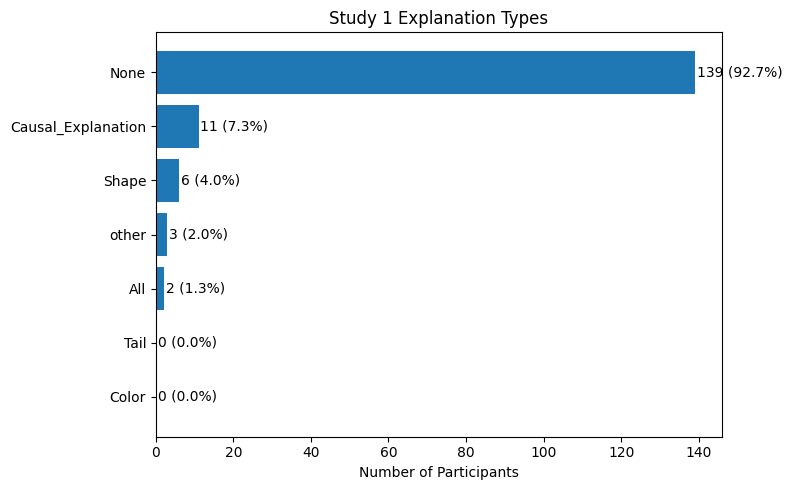


Study 2
             Category  Count    Percent
6               other      2   0.956938
5                 All      5   2.392344
2               Color      8   3.827751
3                Tail     13   6.220096
4                Wing     32  15.311005
1  Causal_Explanation     38  18.181818
0                None    171  81.818182
Total coded participants: 209


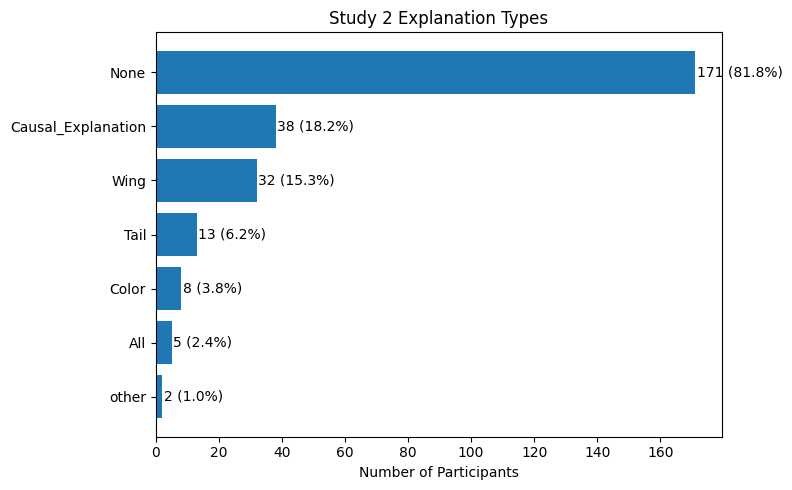


Study 3
             Category  Count    Percent
4               other     28  12.785388
3                feet     33  15.068493
2               color     58  26.484018
1  causal_explanation     80  36.529680
0                none    139  63.470320
Total coded participants: 219


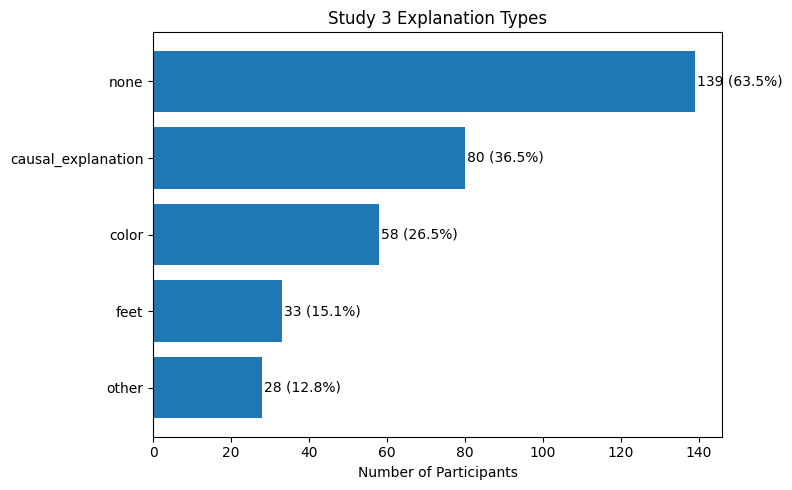


Study 4
             Category  Count    Percent
6          Unnamed: 7      0   0.000000
3                feet     14   6.481481
5               other     19   8.796296
2             stripes     22  10.185185
4        stripes+feet     22  10.185185
1  Causal_Explanation     71  32.870370
0                None    145  67.129630
Total coded participants: 216


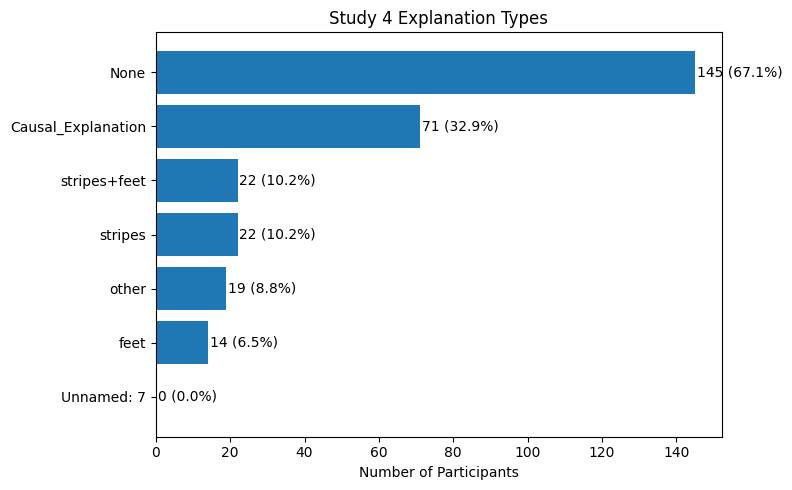


Study 5
             Category  Count    Percent
2             stripes      5   1.718213
3                feet      9   3.092784
5               other      9   3.092784
4        stripes+feet     29   9.965636
1  Causal_Explanation     43  14.776632
0                None    249  85.567010
Total coded participants: 291


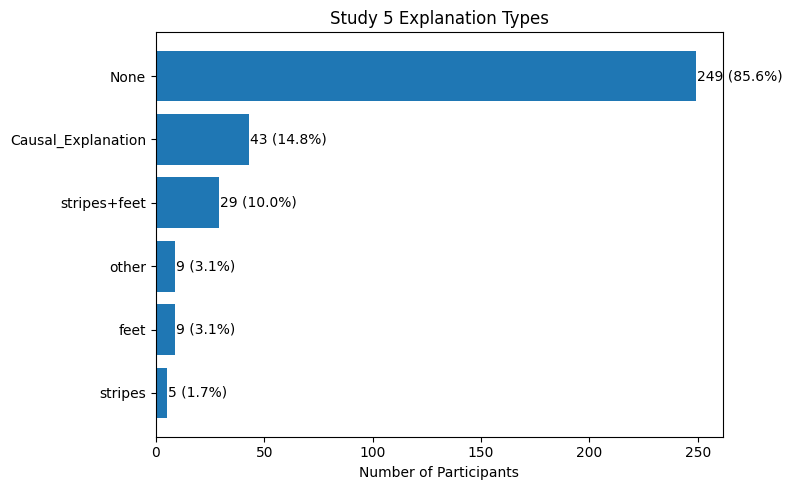

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

base_path = "/Users/sm6511/Desktop/Prediction-Accomodation-Exp/data/Combined/explanationcodes"

studies = range(1, 6)

all_summaries = []

for study in studies:

    file = os.path.join(base_path, f"Explanation_Coding_Study{study}.csv")

    if not os.path.exists(file):
        print(f"Study {study} missing, skipping.")
        continue

    df = pd.read_csv(file)
    df["participant"] = pd.to_numeric(df["participant"], errors="coerce")
    df = df.dropna(subset=["participant"]).copy()
    df["participant"] = df["participant"].astype(int)

    id_cols = ["participant"]
    coding_cols = [c for c in df.columns if c not in id_cols]

    # Force columns to numeric
    for col in coding_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # Treat 'Explanation' as None
    if "Explanation" in df.columns:
        if "None" not in df.columns:
            df["None"] = 0

        df["None"] = ((df["None"] == 1) | (df["Explanation"] == 1)).astype(int)
        df = df.drop(columns=["Explanation"])

    coding_cols = [c for c in df.columns if c not in id_cols]

    # Exclude rows with no coded categories (this occurs because the participant nums not included
    # depended on who was dropped due to failing attention check and not replaced, which was randomly distributed across conditions)
    valid = df[coding_cols].sum(axis=1) > 0
    df = df.loc[valid].copy()

    total = len(df)

    if total == 0:
        print(f"Study {study}: no coded participants, skipping.")
        continue

    summary = (
        df[coding_cols]
        .sum()
        .reset_index()
        .rename(columns={"index": "Category", 0: "Count"})
    )

    summary["Count"] = summary["Count"].astype(int)
    summary["Percent"] = summary["Count"] / total * 100
    summary["Study"] = study
    summary = summary.sort_values("Count")

    all_summaries.append(summary)

    print(f"\nStudy {study}")
    print(summary[["Category", "Count", "Percent"]])
    print(f"Total coded participants: {total}")

    plt.figure(figsize=(8, 5))
    plt.barh(summary["Category"], summary["Count"])

    for i, row in enumerate(summary.itertuples()):
        plt.text(
            row.Count + 0.5,
            i,
            f"{row.Count} ({row.Percent:.1f}%)",
            va="center"
        )

    plt.title(f"Study {study} Explanation Types")
    plt.xlabel("Number of Participants")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

all_summary_df = pd.concat(all_summaries, ignore_index=True)

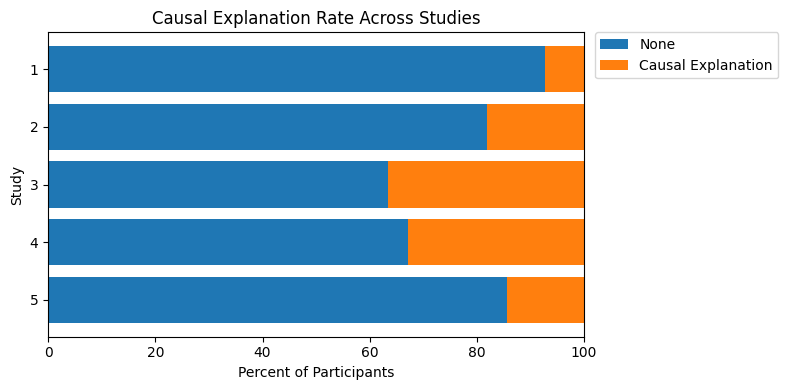

In [10]:
# Horizontal stacked bars showing None vs Causal Explanation for each study

plot_df = (
    all_summary_df[
        all_summary_df["Category"].str.lower().isin(
            ["none", "causal_explanation"]
        )
    ]
    .copy()
)

plot_df["Category"] = plot_df["Category"].replace({
    "causal_explanation": "Causal Explanation",
    "Causal_Explanation": "Causal Explanation",
    "None": "None",
    "none": "None"
})

wide = (
    plot_df
    .pivot(index="Study", columns="Category", values="Percent")
    .fillna(0)
)

# Ensure consistent order
wide = wide.reindex(columns=["None", "Causal Explanation"], fill_value=0)

plt.figure(figsize=(8, 4))

left = np.zeros(len(wide))

for col in wide.columns:
    plt.barh(
        wide.index.astype(str),
        wide[col],
        left=left,
        label=col
    )
    left += wide[col].values

plt.xlim(0, 100)
plt.xlabel("Percent of Participants")
plt.ylabel("Study")
plt.title("Causal Explanation Rate Across Studies")
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [2]:
# Diagnose why None + Causal_Explanation percentages do not add to 100%
# Start with Study 5

import pandas as pd
import os

study = 4
file = os.path.join(
    base_path,
    f"Explanation_Coding_Study{study}.csv"
)

df = pd.read_csv(file)

# Drop summary / non-participant rows
df["participant"] = pd.to_numeric(df["participant"], errors="coerce")
df = df.dropna(subset=["participant"]).copy()
df["participant"] = df["participant"].astype(int)

# Identify coding columns
id_cols = ["participant"]
coding_cols = [c for c in df.columns if c not in id_cols]

# Convert coding columns to numeric
for col in coding_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Treat Explanation as None
if "Explanation" in df.columns:
    if "None" not in df.columns:
        df["None"] = 0

    df["None"] = ((df["None"] == 1) | (df["Explanation"] == 1)).astype(int)
    df = df.drop(columns=["Explanation"])

coding_cols = [c for c in df.columns if c not in id_cols]

# Keep only real coded participants
df["total_codes"] = df[coding_cols].sum(axis=1)
df = df[df["total_codes"] > 0].copy()

total = len(df)

# Main diagnostic flags
df["has_none"] = df["none"] == 1
df["has_causal"] = df["causal_explanation"] == 1

df["none_plus_causal_status"] = pd.Series(
    "neither",
    index=df.index
)

df.loc[df["has_none"] & ~df["has_causal"], "none_plus_causal_status"] = "none_only"
df.loc[~df["has_none"] & df["has_causal"], "none_plus_causal_status"] = "causal_only"
df.loc[df["has_none"] & df["has_causal"], "none_plus_causal_status"] = "both_none_and_causal"

print(f"Study {study}")
print(f"Total coded participants: {total}")

print("\nNone / causal breakdown:")
breakdown = (
    df["none_plus_causal_status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="count")
)
breakdown["percent"] = breakdown["count"] / total * 100
print(breakdown)

print("\nParticipants with neither None nor Causal_Explanation:")
neither = df[df["none_plus_causal_status"] == "neither"]
print(neither[["participant"] + coding_cols + ["total_codes"]])

print("\nParticipants with both None and Causal_Explanation:")
both = df[df["none_plus_causal_status"] == "both_none_and_causal"]
print(both[["participant"] + coding_cols + ["total_codes"]])

print("\nParticipants with multiple total codes:")
multi = df[df["total_codes"] > 1]
print(multi[["participant"] + coding_cols + ["total_codes", "none_plus_causal_status"]])

print("\nCounts for all categories:")
category_counts = (
    df[coding_cols]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "category", 0: "count"})
)
category_counts["percent"] = category_counts["count"] / total * 100
print(category_counts)

KeyError: 'none'